# Outcome Selection and Exploratory Design — Report Section 4

**Purpose:** move from the data-quality audit to a focused question about whether Australia's material progress has coincided with stronger social well-being.

This notebook is self-contained: the cleaning and comparison functions it uses are included below. It uses same-year comparisons and independent pooled survey windows, does not impute missing years, and does not build a weighted composite score. `src/oecd_audit.py` remains the matching tested command-line implementation.


In [1]:
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# make paths work from either the project root or the notebooks folder
PROJECT_ROOT = Path.cwd() / 'submission' if (Path.cwd() / 'submission' / 'OECD Data.csv').exists() else (Path.cwd().parent if Path.cwd().name == 'code' else Path.cwd())
RAW_FILE = PROJECT_ROOT / 'OECD Data.csv'
DATA_FILE = RAW_FILE

sns.set_theme(style='whitegrid', context='notebook')


## Self-contained functions used in this exploration

The indicator definitions, duplicate-key validation, pooled-period treatment, same-year comparisons, Australian endpoint summary, and domain-coverage calculation are shown here rather than hidden behind an import.


In [2]:
# check the source structure before doing any analysis
EXPECTED_COLUMNS = {
    "REF_AREA",
    "Reference area",
    "MEASURE",
    "Measure",
    "UNIT_MEASURE",
    "Unit of measure",
    "AGE",
    "SEX",
    "EDUCATION_LEV",
    "DOMAIN",
    "Domain",
    "TIME_PERIOD",
    "OBS_VALUE",
    "OBS_STATUS",
    "Observation status",
}


@dataclass(frozen=True)
class IndicatorSpec:
    direction: str
    indicator_type: str
    frequency: str
    pdf_pages: str
    caveat: str


# keep direction and comparability notes beside each indicator
INDICATOR_SPECS = {
    "1_1": IndicatorSpec(
        "higher",
        "country average",
        "annual",
        "3",
        "National-accounts income includes social transfers in kind and capital consumption; PPP conversion supports level comparison but is not a cash-income measure.",
    ),
    "1_2": IndicatorSpec(
        "lower",
        "vertical inequality",
        "irregular/periodic",
        "4",
        "Household survey or administrative sources differ; both tails of the income distribution can be under-covered or under-reported.",
    ),
    "1_3": IndicatorSpec(
        "higher",
        "country average and vertical inequality",
        "irregular/periodic",
        "4-5",
        "Per-household median excludes private and occupational pensions, is not adjusted for household size, and countries use different CPI classifications.",
    ),
    "2_1": IndicatorSpec(
        "higher",
        "country average",
        "annual",
        "7",
        "Employment means at least one hour of paid work in the reference week; it measures jobholding, not hours, pay, security, or job quality.",
    ),
    "2_2": IndicatorSpec(
        "lower",
        "horizontal inequality",
        "annual/irregular",
        "7-8",
        "The unadjusted gap compares median wages of full-time employees; it does not isolate discrimination and excludes differences driven by employment participation or hours.",
    ),
    "2_7": IndicatorSpec(
        "lower",
        "deprivation",
        "annual",
        "10-11",
        "Threshold-based employee measure; working-time definitions and self-reporting can differ across labour-force surveys.",
    ),
    "3_1": IndicatorSpec(
        "lower",
        "deprivation",
        "irregular/periodic",
        "12",
        "Survey coverage differs and several countries lack information on subsidised tenants; household composition affects the overcrowding definition.",
    ),
    "3_2": IndicatorSpec(
        "higher",
        "country average",
        "annual",
        "12-13",
        "A national-accounts average including imputed owner-occupier rent; it can look stable while renters or low-income households face severe stress. Countries use different COICOP versions.",
    ),
    "4_1": IndicatorSpec(
        "higher",
        "country average",
        "irregular/periodic",
        "14",
        "Time-use surveys differ in survey year, diary design, population coverage, and treatment of simultaneous activities.",
    ),
    "4_3": IndicatorSpec(
        "lower",
        "horizontal inequality",
        "irregular/periodic",
        "14-15",
        "Derived from time-use surveys with sparse, non-aligned years; the sign and composition of paid/unpaid work gaps matter, not only magnitude.",
    ),
    "5_1": IndicatorSpec(
        "higher",
        "country average",
        "annual",
        "16",
        "Period life expectancy applies current age-specific mortality rates to a hypothetical cohort; it is not the predicted lifespan of babies born that year.",
    ),
    "5_3": IndicatorSpec(
        "lower",
        "deprivation",
        "annual",
        "17",
        "Cause-of-death coding and registration practices can differ; the combined outcome hides distinct trends in suicide, alcohol, and drugs.",
    ),
    "6_2": IndicatorSpec(
        "higher",
        "country average",
        "PISA cycle",
        "19-20",
        "PISA covers enrolled 15-year-olds, excluding school dropouts and home-schooled students; cycles are not annual and composition/testing conditions can change.",
    ),
    "7_1_DEP": IndicatorSpec(
        "lower",
        "deprivation",
        "3-year pooled survey windows",
        "21",
        "Gallup samples about 1,000 people per country per year; displayed annual rows repeat pooled 3-year estimates and must not be treated as independent yearly observations.",
    ),
    "7_2": IndicatorSpec(
        "higher",
        "country average",
        "time-use survey waves",
        "21-22",
        "Counts social interaction only when it is the primary activity; survey years and diary methods differ and simultaneous interaction is omitted.",
    ),
    "8_1_DEP": IndicatorSpec(
        "lower",
        "deprivation",
        "survey waves",
        "23",
        "OECD Trust Survey waves are sparse; this is perceived political voice, not an institutional measure of democratic quality.",
    ),
    "8_2": IndicatorSpec(
        "higher",
        "country average",
        "election-based",
        "23",
        "Years reflect different election cycles and election types; compulsory voting in Australia and several peers makes turnout levels structurally non-comparable.",
    ),
    "9_2": IndicatorSpec(
        "lower",
        "country average",
        "annual to 2020",
        "24",
        "A threshold share above 5 micrograms/m3 can saturate near 100% and conceal meaningful differences in pollution concentration.",
    ),
    "9_3": IndicatorSpec(
        "lower",
        "country average",
        "annual",
        "25",
        "Climate and geography create structural cross-country differences; annual extremes are volatile and should not be interpreted from a single year.",
    ),
    "11_1": IndicatorSpec(
        "higher",
        "country average",
        "sparse survey years",
        "26-27",
        "Question wording, scale anchors, sampled ages, and survey methods differ across countries; only two Australian observations are supplied.",
    ),
    "11_2": IndicatorSpec(
        "lower",
        "deprivation",
        "3-year pooled survey windows",
        "27-28",
        "Gallup samples about 1,000 people per country per year; displayed annual rows repeat pooled 3-year estimates and must not be treated as independent yearly observations.",
    ),
}


In [3]:
def pooled_period(indicator_code: str, year: int) -> str:
    """Return the independent observation window represented by a row."""
    # Gallup rows repeat one estimate across a three-year window
    if indicator_code not in {"7_1_DEP", "11_2"}:
        return str(year)
    if year == 2010:
        return "2008-10"
    if 2011 <= year <= 2013:
        return "2011-13"
    if 2014 <= year <= 2016:
        return "2014-16"
    if 2017 <= year <= 2019:
        return "2017-19"
    if 2020 <= year <= 2022:
        return "2020-22"
    if 2023 <= year <= 2025:
        return "2023-25"
    return str(year)


def load_clean(path: Path = RAW_FILE) -> pd.DataFrame:
    """Validate and return a tidy analysis copy without changing raw data."""
    if not path.exists():
        raise FileNotFoundError(f"Raw OECD file not found: {path}")

    raw = pd.read_csv(path)
    missing_columns = EXPECTED_COLUMNS.difference(raw.columns)
    if missing_columns:
        raise ValueError(f"Missing expected columns: {sorted(missing_columns)}")
    # stop instead of keeping the first duplicate and hiding a possible conflict
    if raw.duplicated(["REF_AREA", "MEASURE", "TIME_PERIOD"]).any():
        raise ValueError("Duplicate country-indicator-year keys require investigation.")
    if raw["OBS_VALUE"].isna().any():
        raise ValueError("Missing observation values require investigation.")
    unknown = set(raw["MEASURE"]) - set(INDICATOR_SPECS)
    if unknown:
        raise ValueError(f"Add metadata for new indicators: {sorted(unknown)}")

    # keep the analysis fields and rename them for easier use
    tidy = raw[
        [
            "REF_AREA",
            "Reference area",
            "MEASURE",
            "Measure",
            "DOMAIN",
            "Domain",
            "TIME_PERIOD",
            "OBS_VALUE",
            "OBS_STATUS",
            "Observation status",
            "UNIT_MEASURE",
            "Unit of measure",
            "BASE_PER",
        ]
    ].rename(
        columns={
            "REF_AREA": "country_code",
            "Reference area": "country",
            "MEASURE": "indicator_code",
            "Measure": "indicator",
            "DOMAIN": "domain_code",
            "Domain": "domain",
            "TIME_PERIOD": "year",
            "OBS_VALUE": "value",
            "OBS_STATUS": "status_code",
            "Observation status": "status",
            "UNIT_MEASURE": "unit_code",
            "Unit of measure": "unit",
            "BASE_PER": "base_period",
        }
    )
    tidy["year"] = pd.to_numeric(tidy["year"], errors="raise").astype("int16")
    tidy["value"] = pd.to_numeric(tidy["value"], errors="raise")
    # any OECD status other than A needs extra care
    tidy["is_flagged"] = tidy["status_code"].ne("A")
    tidy["better_direction"] = tidy["indicator_code"].map(
        {code: spec.direction for code, spec in INDICATOR_SPECS.items()}
    )
    tidy["independent_period"] = [
        pooled_period(code, int(year))
        for code, year in zip(tidy["indicator_code"], tidy["year"], strict=True)
    ]
    return tidy.sort_values(["country_code", "indicator_code", "year"]).reset_index(drop=True)


In [4]:
def build_same_year_comparisons(data: pd.DataFrame) -> pd.DataFrame:
    """Compare Australia only with countries reporting the same indicator/year."""
    rows: list[dict[str, object]] = []
    for aus_row in data.loc[data["country_code"].eq("AUS")].itertuples(index=False):
        # compare Australia with countries reporting the same indicator and year
        peers = data.loc[
            data["indicator_code"].eq(aus_row.indicator_code)
            & data["year"].eq(aus_row.year)
        ].copy()
        # orient the rank so a larger percentile always means a better result
        ascending = aus_row.better_direction == "lower"
        peers["favourable_rank"] = peers["value"].rank(
            ascending=ascending, method="average"
        )
        aus_rank = float(
            peers.loc[peers["country_code"].eq("AUS"), "favourable_rank"].iloc[0]
        )
        n = len(peers)
        favourable_percentile = 100.0 if n == 1 else 100 * (n - aus_rank) / (n - 1)
        rows.append(
            {
                "indicator_code": aus_row.indicator_code,
                "indicator": aus_row.indicator,
                "domain": aus_row.domain,
                "year": aus_row.year,
                "independent_period": aus_row.independent_period,
                "australia_value": aus_row.value,
                "australia_status_code": aus_row.status_code,
                "better_direction": aus_row.better_direction,
                "same_year_country_count": n,
                "same_year_median": peers["value"].median(),
                "same_year_q25": peers["value"].quantile(0.25),
                "same_year_q75": peers["value"].quantile(0.75),
                "australia_favourable_rank": aus_rank,
                "australia_favourable_percentile": favourable_percentile,
                "comparison_is_thin": n < 20,
                "any_peer_flagged": bool(peers["is_flagged"].any()),
            }
        )
    return pd.DataFrame(rows).sort_values(["indicator_code", "year"])


In [5]:
def build_australia_summary(
    data: pd.DataFrame, comparisons: pd.DataFrame, through_year: int = 2024
) -> pd.DataFrame:
    """Create an endpoint and current-position scouting table, not a causal result."""
    rows: list[dict[str, object]] = []
    aus = data.loc[data["country_code"].eq("AUS") & data["year"].le(through_year)]
    for code, group in aus.groupby("indicator_code", sort=True):
        # use one row per real period so pooled rows do not inflate the trend
        independent = group.drop_duplicates("independent_period", keep="last").sort_values("year")
        first = independent.iloc[0]
        last = independent.iloc[-1]
        matching = comparisons.loc[
            comparisons["indicator_code"].eq(code)
            & comparisons["year"].eq(last["year"])
        ].iloc[0]
        absolute_change = last["value"] - first["value"]
        percent_change = (
            100 * absolute_change / abs(first["value"]) if first["value"] != 0 else np.nan
        )
        direction = INDICATOR_SPECS[code].direction
        favourable_change = absolute_change if direction == "higher" else -absolute_change
        rows.append(
            {
                "indicator_code": code,
                "indicator": first["indicator"],
                "domain": first["domain"],
                "frequency": INDICATOR_SPECS[code].frequency,
                "first_year": int(first["year"]),
                "last_year_through_2024": int(last["year"]),
                "first_value": first["value"],
                "last_value": last["value"],
                "absolute_change": absolute_change,
                "percent_change": percent_change,
                "change_is_favourable": bool(favourable_change > 0),
                "independent_period_count": len(independent),
                "latest_same_year_country_count": int(matching["same_year_country_count"]),
                "latest_same_year_median": matching["same_year_median"],
                "latest_favourable_percentile": matching[
                    "australia_favourable_percentile"
                ],
                "latest_comparison_is_thin": bool(matching["comparison_is_thin"]),
            }
        )
    return pd.DataFrame(rows)


def build_domain_coverage(
    data: pd.DataFrame, country_code: str | None = None, through_year: int = 2024
) -> pd.DataFrame:
    """Summarise coverage by domain without treating pooled rows as independent.

    ``observation_count`` is the number of displayed rows. In contrast,
    ``independent_observation_count`` counts unique country-indicator-period
    combinations and is the appropriate coverage measure for pooled surveys.
    """
    subset = data.loc[data["year"].le(through_year)].copy()
    if country_code is not None:
        subset = subset.loc[subset["country_code"].eq(country_code)].copy()
    if subset.empty:
        raise ValueError("No observations available for the requested domain coverage.")

    # count real periods separately from the repeated rows shown in the CSV
    independent = subset.drop_duplicates(
        ["country_code", "indicator_code", "independent_period"]
    )
    independent_counts = (
        independent.groupby(["domain_code", "domain"])
        .size()
        .rename("independent_observation_count")
        .reset_index()
    )
    summary = (
        subset.groupby(["domain_code", "domain"], as_index=False)
        .agg(
            indicators=(
                "indicator",
                lambda x: " | ".join(sorted(pd.Series(x).dropna().unique())),
            ),
            indicator_codes=(
                "indicator_code",
                lambda x: " | ".join(sorted(pd.Series(x).dropna().unique())),
            ),
            indicator_count=("indicator_code", "nunique"),
            observation_count=("value", "size"),
            country_count=("country_code", "nunique"),
            first_year=("year", "min"),
            last_year=("year", "max"),
        )
        .merge(independent_counts, on=["domain_code", "domain"], how="left")
    )
    summary["share_of_displayed_rows_pct"] = (
        summary["observation_count"].div(len(subset)).mul(100).round(2)
    )
    summary = summary.sort_values(
        ["independent_observation_count", "domain"], ascending=[False, True]
    ).reset_index(drop=True)
    summary.insert(0, "coverage_rank", summary.index + 1)
    return summary


In [6]:
# validate the data, then assess Australia's change and position through 2024
df = load_clean(DATA_FILE)
comparisons = build_same_year_comparisons(df)
australia_summary = build_australia_summary(df, comparisons, through_year=2024)
print(f'{len(df):,} rows; {df.country_code.nunique()} countries; {df.indicator_code.nunique()} indicators')
display(australia_summary)

8,806 rows; 47 countries; 21 indicators


,indicator_code,indicator,domain,frequency,first_year,last_year_through_2024,first_value,last_value,absolute_change,percent_change,change_is_favourable,independent_period_count,latest_same_year_country_count,latest_same_year_median,latest_favourable_percentile,latest_comparison_is_thin
0,11_1,Life satisfaction,Subjective well-being,sparse survey years,2019,2020,7.500000,7.200000,-0.300000,-4.000000,False,2,6,7.295000,40.000000,True
1,11_2,Negative affect balance,Subjective well-being,3-year pooled survey windows,2010,2024,12.244020,14.853043,2.609023,21.308548,False,6,47,12.391960,26.086957,False
2,1_1,Households and NPISHs net adjusted disposable ...,Income and wealth,annual,2010,2024,44625.000000,50629.000000,6004.000000,13.454342,True,15,32,42721.000000,80.645161,False
3,1_2,Top average household disposable income quintile,Income and wealth,irregular/periodic,2012,2020,5.521159,5.564457,0.043298,0.784222,False,5,39,5.166203,42.105263,False
4,1_3,Median net wealth,Income and wealth,irregular/periodic,2012,2020,347898.000000,369820.000000,21922.000000,6.301272,True,4,9,204476.000000,87.500000,True
5,2_1,Employment rate,Work and job quality,annual,2010,2024,75.444000,80.262000,4.818000,6.386194,True,15,45,79.865000,54.545455,False
6,2_2,Gender wage gap,Work and job quality,annual/irregular,2010,2024,14.042934,10.671213,-3.371721,-24.010089,True,15,31,10.671213,50.000000,False
7,2_7,Long hours in paid work,Work and job quality,annual,2010,2024,13.990000,10.180000,-3.810000,-27.233738,True,15,41,3.860000,20.000000,False
8,3_2,Housing affordability,Housing,annual,2010,2024,80.764590,80.748138,-0.016452,-0.020370,False,15,33,80.748138,50.000000,False
9,5_1,Life expectancy at birth,Health,annual,2010,2023,81.700000,83.000000,1.300000,1.591187,True,14,46,81.500000,78.888889,False


## Domain coverage

These are coverage summaries, not rankings of domain performance. `observation_count` counts displayed rows; `independent_observation_count` prevents repeated pooled years from being mistaken for new evidence.

In [7]:
# these ranks describe data coverage, not which domain matters most
domain_all = build_domain_coverage(df, through_year=2024)
domain_au = build_domain_coverage(df, country_code='AUS', through_year=2024)
display(domain_all)
display(domain_au)

,coverage_rank,domain_code,domain,indicators,indicator_codes,indicator_count,observation_count,country_count,first_year,last_year,independent_observation_count,share_of_displayed_rows_pct
0,1,HSL_2,Work and job quality,Employment rate | Gender wage gap | Long hours...,2_1 | 2_2 | 2_7,3,1772,47,2010,2024,1772,20.66
1,2,HSL_5,Health,"Deaths from suicide, alcohol, drugs | Life exp...",5_1 | 5_3,2,1283,47,2010,2024,1283,14.96
2,3,HSL_9,Environmental quality,Exposed to air pollution | Exposure to extreme...,9_2 | 9_3,2,1211,47,2010,2024,1211,14.12
3,4,HSL_1,Income and wealth,Households and NPISHs net adjusted disposable ...,1_1 | 1_2 | 1_3,3,1138,42,2010,2024,1138,13.27
4,5,HSL_3,Housing,Households living in overcrowded conditions | ...,3_1 | 3_2,2,1062,40,2010,2024,1062,12.38
5,6,HSL_11,Subjective well-being,Life satisfaction | Negative affect balance,11_1 | 11_2,2,929,47,2010,2024,506,10.83
6,7,HSL_7,Social connections,Lack of social support | Time spent in social ...,7_1_DEP | 7_2,2,728,47,2010,2024,305,8.49
7,8,HSL_8,Civic engagement,Not having a say in government | Voter turnout,8_1_DEP | 8_2,2,247,47,2010,2024,247,2.88
8,9,HSL_6,Knowledge and skills,Student mathematics skills,6_2,1,154,39,2012,2022,154,1.80
9,10,HSL_4,Work-life balance,Gender gap in working hours | Time off,4_1 | 4_3,2,51,16,2010,2022,51,0.59


,coverage_rank,domain_code,domain,indicators,indicator_codes,indicator_count,observation_count,country_count,first_year,last_year,independent_observation_count,share_of_displayed_rows_pct
0,1,HSL_2,Work and job quality,Employment rate | Gender wage gap | Long hours...,2_1 | 2_2 | 2_7,3,45,1,2010,2024,45,24.73
1,2,HSL_5,Health,"Deaths from suicide, alcohol, drugs | Life exp...",5_1 | 5_3,2,29,1,2010,2024,29,15.93
2,3,HSL_9,Environmental quality,Exposed to air pollution | Exposure to extreme...,9_2 | 9_3,2,26,1,2010,2024,26,14.29
3,4,HSL_1,Income and wealth,Households and NPISHs net adjusted disposable ...,1_1 | 1_2 | 1_3,3,24,1,2010,2024,24,13.19
4,5,HSL_3,Housing,Housing affordability,3_2,1,15,1,2010,2024,15,8.24
5,6,HSL_11,Subjective well-being,Life satisfaction | Negative affect balance,11_1 | 11_2,2,17,1,2010,2024,8,9.34
6,7,HSL_8,Civic engagement,Not having a say in government | Voter turnout,8_1_DEP | 8_2,2,7,1,2010,2023,7,3.85
7,8,HSL_7,Social connections,Lack of social support,7_1_DEP,1,15,1,2010,2024,6,8.24
8,9,HSL_6,Knowledge and skills,Student mathematics skills,6_2,1,4,1,2012,2022,4,2.20


## Economic and social indicators

The table separates direction of change from current international position. A favourable percentile near 100 means Australia compares well among countries reporting the same indicator in the same year.

In [8]:
# compare material progress with the main social and well-being outcomes
FOCUS_CODES = ['1_1', '1_2', '2_1', '2_2', '2_7', '3_2', '5_1', '5_3', '6_2', '7_1_DEP', '8_1_DEP', '11_1', '11_2']
focus = australia_summary.loc[australia_summary['indicator_code'].isin(FOCUS_CODES)].copy()
display(focus[[
    'indicator_code', 'indicator', 'first_year', 'last_year_through_2024',
    'first_value', 'last_value', 'percent_change', 'change_is_favourable',
    'independent_period_count', 'latest_same_year_country_count',
    'latest_favourable_percentile', 'latest_comparison_is_thin',
]])

,indicator_code,indicator,first_year,last_year_through_2024,first_value,last_value,percent_change,change_is_favourable,independent_period_count,latest_same_year_country_count,latest_favourable_percentile,latest_comparison_is_thin
0,11_1,Life satisfaction,2019,2020,7.500000,7.200000,-4.000000,False,2,6,40.000000,True
1,11_2,Negative affect balance,2010,2024,12.244020,14.853043,21.308548,False,6,47,26.086957,False
2,1_1,Households and NPISHs net adjusted disposable ...,2010,2024,44625.000000,50629.000000,13.454342,True,15,32,80.645161,False
3,1_2,Top average household disposable income quintile,2012,2020,5.521159,5.564457,0.784222,False,5,39,42.105263,False
5,2_1,Employment rate,2010,2024,75.444000,80.262000,6.386194,True,15,45,54.545455,False
6,2_2,Gender wage gap,2010,2024,14.042934,10.671213,-24.010089,True,15,31,50.000000,False
7,2_7,Long hours in paid work,2010,2024,13.990000,10.180000,-27.233738,True,15,41,20.000000,False
8,3_2,Housing affordability,2010,2024,80.764590,80.748138,-0.020370,False,15,33,50.000000,False
9,5_1,Life expectancy at birth,2010,2023,81.700000,83.000000,1.591187,True,14,46,78.888889,False
10,5_3,"Deaths from suicide, alcohol, drugs",2010,2024,14.881623,22.158189,48.896321,False,15,18,47.058824,True


## Direction of travel

Each indicator is indexed to 100 at its first independent Australian period and oriented so values above 100 indicate improvement. This shows direction only; it does not claim the indicators are equally important or directly comparable in magnitude.

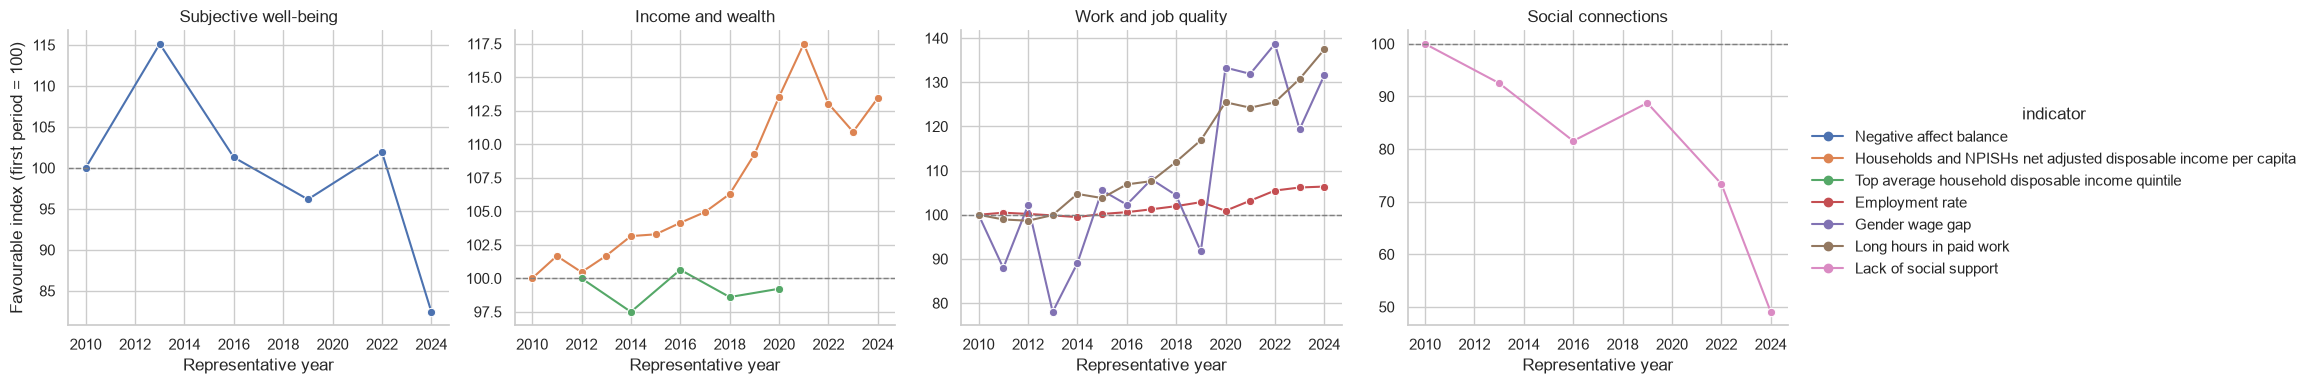

In [9]:
TREND_CODES = ['1_1', '1_2', '2_1', '2_2', '2_7', '7_1_DEP', '11_2']
# keep one representative row from each pooled period
trend = (df.loc[df['country_code'].eq('AUS') & df['year'].le(2024) & df['indicator_code'].isin(TREND_CODES)]
           .drop_duplicates(['indicator_code', 'independent_period'], keep='last')
           .sort_values(['indicator_code', 'year']).copy())
# orient each series so values above 100 always mean improvement
first_values = trend.groupby('indicator_code')['value'].transform('first')
trend['favourable_index'] = trend['value'].div(first_values).mul(100)
lower_is_better = trend['better_direction'].eq('lower')
trend.loc[lower_is_better, 'favourable_index'] = first_values[lower_is_better].div(trend.loc[lower_is_better, 'value']).mul(100)

g = sns.relplot(
    data=trend, x='year', y='favourable_index', col='domain', hue='indicator',
    kind='line', marker='o', facet_kws={'sharex': False, 'sharey': False},
    height=4, aspect=1.15,
)
g.set_axis_labels('Representative year', 'Favourable index (first period = 100)')
g.set_titles('{col_name}')
for ax in g.axes.flat:
    ax.axhline(100, color='grey', linewidth=1, linestyle='--')
plt.show()

## Same-year English-speaking peer sensitivity

Canada, New Zealand, the United Kingdom and the United States are used as one interpretable sensitivity group. They are not assumed to be the only valid peers.

In [10]:
# use a small and easy-to-explain peer group as a sensitivity check
PEERS = ['CAN', 'NZL', 'GBR', 'USA']
peer_rows = []
for code in TREND_CODES:
    series = df.loc[df['indicator_code'].eq(code) & df['year'].le(2024)]
    aus = (series.loc[series['country_code'].eq('AUS')]
           .drop_duplicates('independent_period', keep='last')
           .sort_values('year'))
    peer = (series.loc[series['country_code'].isin(PEERS)]
            .groupby('year', as_index=False)
            .agg(peer_median=('value', 'median'), peer_count=('country_code', 'nunique')))
    # require at least three peers so one country does not drive the median
    common = aus.merge(peer, on='year').loc[lambda x: x['peer_count'].ge(3)]
    if common.empty:
        continue
    first, last = common.iloc[0], common.iloc[-1]
    peer_rows.append({
        'indicator_code': code, 'indicator': first['indicator'],
        'first_year': int(first['year']), 'last_year': int(last['year']),
        'australia_first': first['value'], 'australia_last': last['value'],
        'peer_median_first': first['peer_median'], 'peer_median_last': last['peer_median'],
        'latest_peer_count': int(last['peer_count']),
    })
peer_summary = pd.DataFrame(peer_rows)
display(peer_summary)

,indicator_code,indicator,first_year,last_year,australia_first,australia_last,peer_median_first,peer_median_last,latest_peer_count
0,1_1,Households and NPISHs net adjusted disposable ...,2010,2024,44625.000000,50629.000000,40255.000000,46176.000000,3
1,1_2,Top average household disposable income quintile,2012,2020,5.521159,5.564457,5.906659,5.680122,4
2,2_1,Employment rate,2010,2024,75.444000,80.262000,74.891000,79.705000,4
3,2_2,Gender wage gap,2010,2024,14.042934,10.671213,19.021058,14.818163,4
4,2_7,Long hours in paid work,2010,2024,13.990000,10.180000,11.240000,9.195000,4
5,7_1_DEP,Lack of social support,2010,2024,4.926543,10.043193,4.841900,9.251599,4
6,11_2,Negative affect balance,2010,2024,12.244020,14.853043,10.872813,12.881439,4


## Recommended research question

> **Has Australia's material progress since 2010 coincided with better social well-being, or has a gap opened relative to comparable countries?**

Suggested subquestions:

1. Did household income and employment improve relative to same-year peers?
2. Were gains accompanied by lower income/wage inequality and fewer long working hours?
3. Did social support and negative affect improve, and was Australia's change unusual among peers?

Before confirmatory analysis, fix the indicator set, peer definitions, primary period and robustness checks. Treat these patterns as exploratory and avoid causal wording.

EDA

In [11]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd() / 'submission' if (Path.cwd() / 'submission' / 'OECD Data.csv').exists() else (Path.cwd().parent if Path.cwd().name == 'code' else Path.cwd())
sys.path.insert(0, str(PROJECT_ROOT.parent))
# include the extension so pandas opens the tracked CSV
DATA_FILE = PROJECT_ROOT / 'data' / 'OECD_cleaned_version.csv'
sns.set_theme(style='whitegrid', context='notebook')

In [12]:
# AUS Health EDA

import pandas as pd
from IPython.display import display

df = pd.read_csv(DATA_FILE)

health_df = df[df["domain"] == "Health"].copy()

health_2023 = health_df[health_df["year"] == 2023].copy()

# Life Expectancy

life_expectancy = health_2023[
    health_2023["indicator"] == "Life expectancy at birth"
].copy()

life_expectancy = life_expectancy.sort_values("value", ascending=False)

# give countries with the same value the same rank
life_expectancy["rank"] = life_expectancy["value"].rank(ascending=False, method="min").astype(int)

display(life_expectancy[["rank", "country", "value", "unit"]].head(10))

display(
    life_expectancy[life_expectancy["country"] == "Australia"]
    [["rank", "country", "value", "unit"]]
)

# Deaths from suicide, alcohol, drugs ranking

deaths = health_2023[
    health_2023["indicator"] == "Deaths from suicide, alcohol, drugs"
].copy()

deaths = deaths.sort_values("value", ascending=True)

# lower mortality is better, while equal values share a rank
deaths["rank"] = deaths["value"].rank(ascending=True, method="min").astype(int)

display(deaths[["rank", "country", "value", "unit"]].head(10))

display(
    deaths[deaths["country"] == "Australia"]
    [["rank", "country", "value", "unit"]]
)

,rank,country,value,unit
2685,1,Switzerland,84.3,Years
2431,2,Japan,84.1,Years
2657,3,Spain,84.0,Years
2403,4,Israel,83.8,Years
2417,5,Italy,83.5,Years
2445,5,Korea,83.5,Years
2487,7,Luxembourg,83.4,Years
2671,7,Sweden,83.4,Years
2544,9,Norway,83.1,Years
2107,10,Australia,83.0,Years


,rank,country,value,unit
2107,10,Australia,83.0,Years


,rank,country,value,unit
1761,1,Israel,7.775470,Deaths per 100 000 inhabitants
2050,2,Türkiye,8.842844,Deaths per 100 000 inhabitants
1775,3,Italy,10.700873,Deaths per 100 000 inhabitants
2023,4,Switzerland,12.771577,Deaths per 100 000 inhabitants
1585,5,Colombia,13.212291,Deaths per 100 000 inhabitants
1993,6,Spain,13.470745,Deaths per 100 000 inhabitants
1599,7,Costa Rica,13.543732,Deaths per 100 000 inhabitants
1876,8,Netherlands,14.618655,Deaths per 100 000 inhabitants
1528,9,Brazil,14.819148,Deaths per 100 000 inhabitants
1960,10,Slovak Republic,15.012714,Deaths per 100 000 inhabitants


,rank,country,value,unit
1485,22,Australia,21.685246,Deaths per 100 000 inhabitants


In [13]:
# Compare Australia with other countries in 2023

selected_countries = [
    "Australia",
    "New Zealand",
    "Canada",
    "United Kingdom",
    "United States",
    "Japan",
    "Korea",
    "Sweden",
    "Netherlands"
]

aus_vs_peers = health_2023[
    health_2023["country"].isin(selected_countries)
].copy()

life_expectancy_peers = aus_vs_peers[
    aus_vs_peers["indicator"] == "Life expectancy at birth"
].copy()

life_expectancy_peers = life_expectancy_peers.sort_values("value", ascending=False)

display(life_expectancy_peers[["country", "value", "unit"]])

deaths_peers = aus_vs_peers[
    aus_vs_peers["indicator"] == "Deaths from suicide, alcohol, drugs"
].copy()

deaths_peers = deaths_peers.sort_values("value", ascending=True)

display(deaths_peers[["country", "value", "unit"]])

,country,value,unit
2431,Japan,84.1,Years
2445,Korea,83.5,Years
2671,Sweden,83.4,Years
2107,Australia,83.0,Years
2530,New Zealand,82.0,Years
2516,Netherlands,81.9,Years
2177,Canada,81.7,Years
2726,United Kingdom,81.0,Years
2740,United States,78.4,Years


,country,value,unit
1876,Netherlands,14.618655,Deaths per 100 000 inhabitants
1789,Japan,20.649031,Deaths per 100 000 inhabitants
2008,Sweden,21.247501,Deaths per 100 000 inhabitants
1485,Australia,21.685246,Deaths per 100 000 inhabitants
2064,United Kingdom,22.468549,Deaths per 100 000 inhabitants
1803,Korea,29.663875,Deaths per 100 000 inhabitants
1556,Canada,34.342097,Deaths per 100 000 inhabitants
2079,United States,37.916688,Deaths per 100 000 inhabitants


In [14]:
# AUS Social 

inequality_indicators = [
    "Top average household disposable income quintile",
    "Gender wage gap",
    "Lack of social support",
    "Not having a say in government"
]

aus_inequality = df[
    (df["country"] == "Australia") &
    (df["indicator"].isin(inequality_indicators))
].copy()

display(aus_inequality[["indicator", "year", "value", "unit"]])

summary = (
    aus_inequality
    .sort_values("year")
    .groupby("indicator")
    .agg(
        first_year=("year", "first"),
        first_value=("value", "first"),
        latest_year=("year", "last"),
        latest_value=("value", "last"),
        unit=("unit", "first")
    )
)

summary["change"] = summary["latest_value"] - summary["first_value"]

# all selected measures are lower-is-better, so a negative change is favourable
summary["change_is_favourable"] = summary["change"] < 0

display(summary)

,indicator,year,value,unit
0,Not having a say in government,2021,46.815718,Percentage of population aged 16-65 years
1,Not having a say in government,2023,35.585077,Percentage of population aged 16-65 years
4451,Top average household disposable income quintile,2012,5.521159,Factor of lowest income quintile
4452,Top average household disposable income quintile,2014,5.662882,Factor of lowest income quintile
4453,Top average household disposable income quintile,2016,5.486118,Factor of lowest income quintile
4454,Top average household disposable income quintile,2018,5.599479,Factor of lowest income quintile
4455,Top average household disposable income quintile,2020,5.564457,Factor of lowest income quintile
5110,Lack of social support,2010,4.926543,Percentage of population aged 15 years or over
5111,Lack of social support,2011,5.324185,Percentage of population aged 15 years or over
5112,Lack of social support,2012,5.324185,Percentage of population aged 15 years or over


,first_year,first_value,latest_year,latest_value,unit,change,change_is_favourable
indicator,,,,,,,
Gender wage gap,2010,14.042934,2024,10.671213,Percentage of wages of men in the same decile,-3.371721,True
Lack of social support,2010,4.926543,2024,10.043193,Percentage of population aged 15 years or over,5.116650,False
Not having a say in government,2021,46.815718,2023,35.585077,Percentage of population aged 16-65 years,-11.230641,True
Top average household disposable income quintile,2012,5.521159,2020,5.564457,Factor of lowest income quintile,0.043298,False
